# ST446 Project: Baseline Model — Logistic Regression

This notebook trains and evaluates Logistic Regression as the interpretable baseline model 
for both layers of the hierarchical classification problem.

- **Layer 1**: On-time (≤15 min) vs Late (>15 min) — trained on full dataset
- **Layer 2**: Minor delay (15–45 min) vs Major delay (>45 min) — trained on late flights only

**Train/test split**: Time-based — 2019–2021 train, 2022 test (~80/20)

**Layer 1**: Evaluated with and without class weights to assess impact of class imbalance (84/16 split)

**Layer 2**: No class weighting needed given near-balanced split (51/49)

## 1. Setup

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)
from pyspark.ml.functions import vector_to_array
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time

sns.set_theme(style="whitegrid", palette="muted")

spark = SparkSession.builder.appName("ST446-LR-Baseline").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/28 11:49:06 WARN Utils: Your hostname, MacBook-Pro-3.local, resolves to a loopback address: 127.0.0.1; using 10.254.86.222 instead (on interface en0)
26/04/28 11:49:06 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 11:49:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


## 2. Load Data and Split

In [2]:
df = spark.read.parquet("data/df_features.parquet")
print(f"Total rows: {df.count():,}")
print("Columns:", df.columns)

# Time-based split: 2019-2021 train, 2022 test
train = df.filter(col("year") <= 2021)
test  = df.filter(col("year") == 2022)

print(f"\nTrain rows: {train.count():,}")
print(f"Test rows:  {test.count():,}")
print(f"Train/test split: {100*train.count()/df.count():.1f}% / {100*test.count()/df.count():.1f}%")

Total rows: 3,480,548
Columns: ['features', 'year', 'delay_class', 'is_late', 'delay_severity']



Train rows: 2,784,642
Test rows:  695,906
Train/test split: 80.0% / 20.0%


## 3. Compute Class Weights for Layer 1

Class weights are computed from the training set only to avoid leakage from the test set. 
The weight for each class is inversely proportional to its frequency.

In [3]:
# Compute class weights from training set
class_counts = train.groupBy("is_late").count().toPandas()
total = class_counts["count"].sum()
n_classes = 2

# weight = total / (n_classes * class_count)
class_counts["weight"] = total / (n_classes * class_counts["count"])
print("Class weights (Layer 1):")
print(class_counts.to_string(index=False))

weight_map = dict(zip(class_counts["is_late"], class_counts["weight"]))

# Add weight column to train and test sets
train_weighted = train.withColumn("class_weight",
    when(col("is_late") == 0, weight_map[0]).otherwise(weight_map[1]))
test_weighted = test.withColumn("class_weight",
    when(col("is_late") == 0, weight_map[0]).otherwise(weight_map[1]))

[Stage 22:================================>                         (5 + 4) / 9]

Class weights (Layer 1):
 is_late   count   weight
       1  422202 3.297760
       0 2362440 0.589357


## 4. Assumption Checks

In [5]:
# 1. Multicollinearity
# distance and distance_group had r=0.92 (near-perfect collinearity).
# distance_group was removed from the feature vector in 04-features.ipynb.
# We verify using the raw data since individual columns are not preserved
# in the engineered feature vector.

df_raw = spark.read.parquet("data/df_final_clean.parquet")
numeric_cols = ["dep_hour", "day_of_week", "month", "distance", "distance_group"]
corr_pd = df_raw.select(numeric_cols).sample(fraction=0.1, seed=42).toPandas()
corr_matrix = corr_pd.corr().round(3)
print("Pairwise correlations (numeric features, 10% sample):")
print(corr_matrix)

# 2. Class separation check
# Both classes must be present across the range of dep_hour to avoid complete separation.
# Check using raw data since dep_hour is packed into the feature vector.
print("\nClass balance check across dep_hour quartiles:")
from pyspark.sql.functions import ntile
from pyspark.sql.window import Window

df_raw_train = df_raw.filter(col("year") <= 2021)
w = Window.orderBy("dep_hour")
df_raw_train.withColumn("quartile", ntile(4).over(w)) \
     .groupBy("quartile", (col("arr_delay") > 15).cast("int").alias("is_late")).count() \
     .orderBy("quartile", "is_late").show()

# 3. Sample size
# LR requires sufficient samples per feature. With ~2.8M training rows
# and 89 features, the ratio is well above the recommended minimum of 10:1.
n_train = train.count()
n_features = 89
print(f"\nSamples per feature: {n_train / n_features:,.0f} (recommended minimum: 10)")

Pairwise correlations (numeric features, 10% sample):
                dep_hour  day_of_week  month  distance  distance_group
dep_hour           1.000       -0.019  0.001     0.066           0.070
day_of_week       -0.019        1.000  0.003     0.003           0.003
month              0.001        0.003  1.000     0.003           0.000
distance           0.066        0.003  0.003     1.000           0.919
distance_group     0.070        0.003  0.000     0.919           1.000

Class balance check across dep_hour quartiles:


+--------+-------+------+
|quartile|is_late| count|
+--------+-------+------+
|       1|      0|641577|
|       1|      1| 54584|
|       2|      0|613433|
|       2|      1| 82728|
|       3|      0|580703|
|       3|      1|115457|
|       4|      0|526727|
|       4|      1|169433|
+--------+-------+------+


Samples per feature: 31,288 (recommended minimum: 10)


## 5. Evaluation Helper

A reusable function to compute all metrics and plot a confusion matrix.

In [6]:
def evaluate_model(predictions, label_col, model_name, include_recall=False):
    """
    Compute AUC-ROC, weighted precision, F0.5, and optionally recall.
    
    Primary metrics (reported for all models):
      - AUC-ROC: overall discriminative ability
      - Weighted Precision: prioritised given operational cost of false positives
        (unnecessary rebooking, crew changes, fuel costs)
      - F0.5: weights precision twice as heavily as recall, consistent with
        the precision-first operational framing
    
    Recall is included for LR only (include_recall=True) to contextualise
    the precision/recall tradeoff as a discussion point.
    """
    binary_eval = BinaryClassificationEvaluator(
        labelCol=label_col, rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    multi_eval_acc = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol="prediction", metricName="accuracy")
    multi_eval_prec = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol="prediction", metricName="weightedPrecision")
    multi_eval_rec = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol="prediction", metricName="weightedRecall")

    auc  = binary_eval.evaluate(predictions)
    acc  = multi_eval_acc.evaluate(predictions)
    prec = multi_eval_prec.evaluate(predictions)
    rec  = multi_eval_rec.evaluate(predictions)

    # F0.5: weights precision twice as heavily as recall
    # F_beta = (1 + beta^2) * (precision * recall) / (beta^2 * precision + recall)
    beta = 0.5
    f05 = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec) if (prec + rec) > 0 else 0.0

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  Accuracy:           {acc:.4f}")
    print(f"  Weighted Precision: {prec:.4f}")
    print(f"  F0.5 Score:         {f05:.4f}")
    print(f"  AUC-ROC:            {auc:.4f}")
    if include_recall:
        print(f"  Weighted Recall:    {rec:.4f}  [shown for LR only — see limitations]")

    # Confusion matrix
    cm_pd = (predictions
             .groupBy(label_col, "prediction")
             .count()
             .toPandas()
             .pivot(index=label_col, columns="prediction", values="count")
             .fillna(0)
             .astype(int))

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm_pd, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix — {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    fname = model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f"Logistic_Regression/cm_{fname}.png", dpi=150, bbox_inches="tight")
    plt.show()

    return {"model": model_name, "accuracy": acc, "precision": prec,
            "recall": rec, "f05": f05, "auc": auc}

results = []  # collect all results for final comparison

## 6. Layer 1 — Logistic Regression (Unweighted)

Baseline without class weights. Expected to be biased toward the majority class (on-time).

Training Layer 1 LR (unweighted)...


Training time: 13.0s



  LR Layer 1 (unweighted)
  Accuracy:           0.8199
  Weighted Precision: 0.8524
  F0.5 Score:         0.8457
  AUC-ROC:            0.6500
  Weighted Recall:    0.8199  [shown for LR only — see limitations]


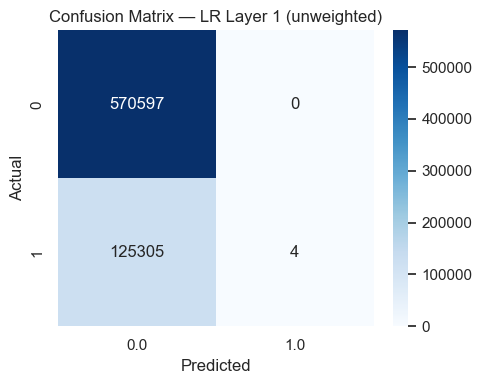

In [7]:
lr_l1 = LogisticRegression(
    featuresCol="features",
    labelCol="is_late",
    maxIter=100
)

print("Training Layer 1 LR (unweighted)...")
t0 = time.time()
model_l1 = lr_l1.fit(train)
train_time_l1 = time.time() - t0
print(f"Training time: {train_time_l1:.1f}s")

preds_l1 = model_l1.transform(test)
res = evaluate_model(preds_l1, "is_late", "LR Layer 1 (unweighted)", include_recall=True)
res["train_time"] = train_time_l1
results.append(res)

## 7. Layer 1 — Logistic Regression (Weighted)

Class weights applied to penalise misclassification of the minority late-flight class.

Training Layer 1 LR (weighted)...


Training time: 7.7s



  LR Layer 1 (weighted)
  Accuracy:           0.6162
  Weighted Precision: 0.7679
  F0.5 Score:         0.7318
  AUC-ROC:            0.6525
  Weighted Recall:    0.6162  [shown for LR only — see limitations]


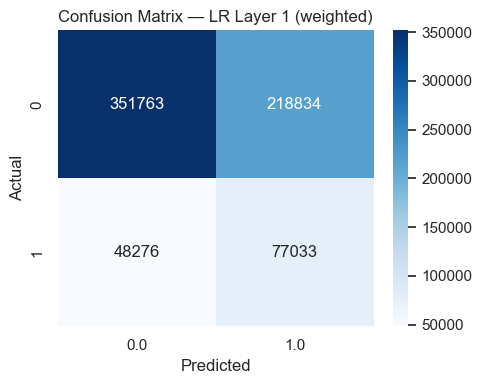

In [8]:
lr_l1_w = LogisticRegression(
    featuresCol="features",
    labelCol="is_late",
    weightCol="class_weight",
    maxIter=100
)

print("Training Layer 1 LR (weighted)...")
t0 = time.time()
model_l1_w = lr_l1_w.fit(train_weighted)
train_time_l1_w = time.time() - t0
print(f"Training time: {train_time_l1_w:.1f}s")

preds_l1_w = model_l1_w.transform(test_weighted)
res = evaluate_model(preds_l1_w, "is_late", "LR Layer 1 (weighted)", include_recall=True)
res["train_time"] = train_time_l1_w
results.append(res)

## 8. Layer 2 — Logistic Regression

Trained on late flights only (is_late == 1). Near-balanced classes so no weighting needed.

Layer 2 train rows: 422,202
Layer 2 test rows:  125,309

Layer 2 train class distribution:
+--------------+------+
|delay_severity| count|
+--------------+------+
|             0|216893|
|             1|205309|
+--------------+------+

Training Layer 2 LR...


Training time: 3.9s



  LR Layer 2
  Accuracy:           0.5688
  Weighted Precision: 0.5681
  F0.5 Score:         0.5683
  AUC-ROC:            0.5899
  Weighted Recall:    0.5688  [shown for LR only — see limitations]


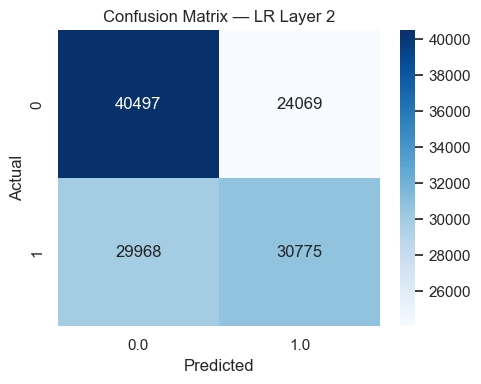

In [9]:
# Filter to late flights only
train_l2 = train.filter(col("is_late") == 1)
test_l2  = test.filter(col("is_late") == 1)

print(f"Layer 2 train rows: {train_l2.count():,}")
print(f"Layer 2 test rows:  {test_l2.count():,}")

# Confirm class balance
print("\nLayer 2 train class distribution:")
train_l2.groupBy("delay_severity").count().orderBy("delay_severity").show()

lr_l2 = LogisticRegression(
    featuresCol="features",
    labelCol="delay_severity",
    maxIter=100
)

print("Training Layer 2 LR...")
t0 = time.time()
model_l2 = lr_l2.fit(train_l2)
train_time_l2 = time.time() - t0
print(f"Training time: {train_time_l2:.1f}s")

preds_l2 = model_l2.transform(test_l2)
res = evaluate_model(preds_l2, "delay_severity", "LR Layer 2", include_recall=True)
res["train_time"] = train_time_l2
results.append(res)

## 9. Results Summary

In [10]:
results_df = pd.DataFrame(results)
results_df[["accuracy", "precision", "f05", "auc"]] = \
    results_df[["accuracy", "precision", "f05", "auc"]].round(4)
results_df["train_time"] = results_df["train_time"].round(1).astype(str) + "s"
print(results_df[["model", "accuracy", "precision", "f05", "auc", "train_time"]].to_string(index=False))

# Save results for later comparison across models
results_df.to_csv("Logistic_Regression/results_lr.csv", index=False)
print("\nSaved to results_lr.csv")

                  model  accuracy  precision    f05    auc train_time
LR Layer 1 (unweighted)    0.8199     0.8524 0.8457 0.6500      13.0s
  LR Layer 1 (weighted)    0.6162     0.7679 0.7318 0.6525       7.7s
             LR Layer 2    0.5688     0.5681 0.5683 0.5899       3.9s

Saved to results_lr.csv


## 10. Feature Coefficients (Layer 1 Weighted)

LR coefficients indicate which features most strongly predict late arrivals. 
Positive coefficients increase the probability of being late.

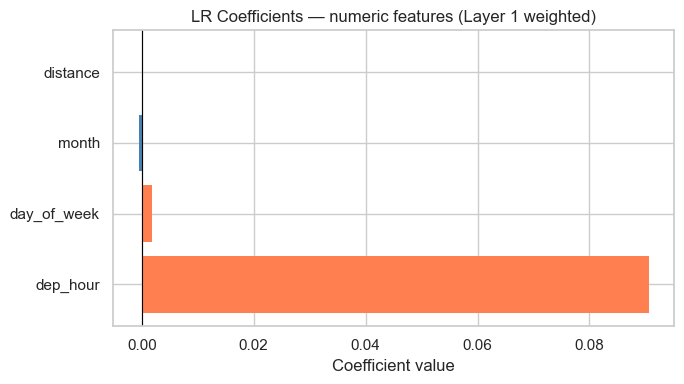

In [11]:
# Extract coefficients for numeric features only
numeric_cols = ["dep_hour", "day_of_week", "month", "distance"]
coeffs = model_l1_w.coefficients.toArray()[:len(numeric_cols)]

coeff_df = pd.DataFrame({"feature": numeric_cols, "coefficient": coeffs})
coeff_df = coeff_df.reindex(coeff_df["coefficient"].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["coral" if c > 0 else "steelblue" for c in coeff_df["coefficient"]]
ax.barh(coeff_df["feature"], coeff_df["coefficient"], color=colors, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("LR Coefficients — numeric features (Layer 1 weighted)")
ax.set_xlabel("Coefficient value")
plt.tight_layout()
plt.savefig("Logistic_Regression/lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Scalability Analysis

We evaluate how LR training time scales with dataset size by training on 25%, 50%, 75%, 
and 100% of the training set and recording wall-clock time. This demonstrates Spark's 
distributed processing behaviour under increasing data volume.

Note: experiments run on a single local machine (intra-node parallelism only). 
Multi-node speedup would require a Dataproc cluster.

Training on 25% of data (697,147 rows)...


  Time: 4.1s | Throughput: 169,203 rows/s
Training on 50% of data (1,392,496 rows)...


  Time: 5.4s | Throughput: 258,576 rows/s
Training on 75% of data (2,087,352 rows)...


  Time: 5.7s | Throughput: 364,713 rows/s
Training on 100% of data (2,784,642 rows)...


  Time: 6.0s | Throughput: 462,777 rows/s

Scalability summary:
 fraction    rows  train_time_s  throughput_rows_per_s
     0.25  697147          4.12               169203.0
     0.50 1392496          5.39               258576.0
     0.75 2087352          5.72               364713.0
     1.00 2784642          6.02               462777.0


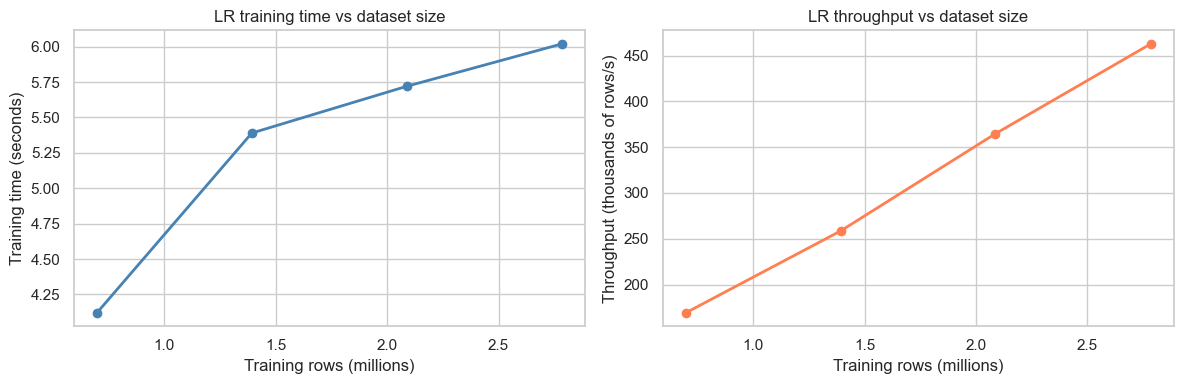

In [12]:
fractions = [0.25, 0.50, 0.75, 1.00]
scalability_results = []

lr_scale = LogisticRegression(
    featuresCol="features",
    labelCol="is_late",
    weightCol="class_weight",
    maxIter=100
)

for frac in fractions:
    if frac < 1.0:
        sample = train_weighted.sample(fraction=frac, seed=42)
    else:
        sample = train_weighted
    
    n_rows = sample.count()
    print(f"Training on {frac*100:.0f}% of data ({n_rows:,} rows)...")
    
    t0 = time.time()
    lr_scale.fit(sample)
    elapsed = time.time() - t0
    
    throughput = n_rows / elapsed
    scalability_results.append({
        "fraction": frac,
        "rows": n_rows,
        "train_time_s": round(elapsed, 2),
        "throughput_rows_per_s": round(throughput, 0)
    })
    print(f"  Time: {elapsed:.1f}s | Throughput: {throughput:,.0f} rows/s")

scale_df = pd.DataFrame(scalability_results)
print("\nScalability summary:")
print(scale_df.to_string(index=False))
scale_df.to_csv("Logistic_Regression/scalability_lr.csv", index=False)

# Plot training time vs data size
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(scale_df["rows"] / 1e6, scale_df["train_time_s"],
             marker="o", color="steelblue", linewidth=2)
axes[0].set_title("LR training time vs dataset size")
axes[0].set_xlabel("Training rows (millions)")
axes[0].set_ylabel("Training time (seconds)")

axes[1].plot(scale_df["rows"] / 1e6, scale_df["throughput_rows_per_s"] / 1e3,
             marker="o", color="coral", linewidth=2)
axes[1].set_title("LR throughput vs dataset size")
axes[1].set_xlabel("Training rows (millions)")
axes[1].set_ylabel("Throughput (thousands of rows/s)")

plt.tight_layout()
plt.savefig("Logistic_Regression/scalability_lr.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# THIS STAYS AT THE END
spark.stop()